In [1]:
from math import log
from typing import Dict, List, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt
import nfl_data_py as nfl
rng=np.random.default_rng()
def load_weekly_games(season: int, include_playoffs: bool = True):
    sched = nfl.import_schedules([season])

    if include_playoffs:
        sched = sched[sched["game_type"].isin(["REG", "WC", "DIV", "CON", "SB"])]
    else:
        sched = sched[sched["game_type"] == "REG"]

    sched = sched.dropna(subset=["home_score", "away_score", "week"])
    sched["week"] = sched["week"].astype(int)

    weekly = {}
    for wk, dfw in sched.groupby("week"):
        weekly[wk] = [
            (h, a, float(hs), float(as_), None)
            for h, a, hs, as_ in dfw[
                ["home_team", "away_team", "home_score", "away_score"]
            ].to_numpy()
        ]
    return weekly
def elo_expected(ra: float, rb: float, H: float = 0.0) -> float:
    """Expected score for A vs B with home-field offset H (Elo points; + favors A)."""
    return 1.0 / (1.0 + 10 ** (-(ra - rb + H) / 400.0))

def elo_update(ra: float, rb: float, score_a: float,
               K: float = 20.0, H: float = 0.0,
               margin: Optional[int] = None) -> Tuple[float, float]:
    """
    One-game Elo update for A vs B.
    score_a: 1.0 win, 0.5 tie, 0.0 loss (then score_b = 1 - score_a)
    margin: optional integer margin of victory for A (abs(score diff)); None = no MoV scaling
    """
    ea = elo_expected(ra, rb, H)
    eb = 1.0 - ea
    mov_mult = 1.0
    if margin is not None:
        mov_mult = log(margin + 1.0) * (2.2 / (0.001 * abs(ra - rb) + 2.2))
    ke = K * mov_mult
    ra_new = ra + ke * (score_a - ea)
    rb_new = rb + ke * ((1.0 - score_a) - eb)
    return ra_new, rb_new

def apply_week(ratings: Dict[str, float],
               games: List[Tuple[str, str, float, float, Optional[int]]],
               K: float = 20.0, home_field: float = 55.0) -> Dict[str, float]:
    """
    Batch-update a week of games.
    games entries: (home_team, away_team, home_score, away_score, margin_override)
    If margin_override is None, margin = abs(home_score - away_score).
    """
    new_r = ratings.copy()
    for home, away, hs, as_, m in games:
        home, away = canon_team(home), canon_team(away)   # <-- add this line
        ra = new_r.get(home, 1500.0)
        rb = new_r.get(away, 1500.0)
        # result from home-team perspective
        if hs > as_:
            sh = 1.0
        elif hs == as_:
            sh = 0.5
        else:
            sh = 0.0
        margin = abs(hs - as_) if m is None else abs(m)
        ra2, rb2 = elo_update(ra, rb, sh, K=K, H=home_field, margin=margin)
        new_r[home], new_r[away] = ra2, rb2
    return new_r

def win_prob(team_a: str, team_b: str,
             ratings: Dict[str, float], home_for_a: bool = True,
             home_field: float = 55.0) -> float:
    """Pre-game win probability for A over B."""
    ra = ratings.get(team_a, 1500.0)
    rb = ratings.get(team_b, 1500.0)
    H = home_field if home_for_a else 0.0
    return elo_expected(ra, rb, H)
TEAM_ALIASES = {
    # Raiders
    "OAK": "LV",
    # Rams
    "STL": "LA",
    # Chargers
    "SD": "LAC",
    # Common older/relocation/name variants that show up in nfl_data_py schedules
    "JAC": "JAX",
    "WSH": "WAS",
    # If you ever go further back:
    "LA": "LA",      # (kept same)
    "LAR": "LA",     # sometimes appears
    "RAM": "LA",     # rare
}

def canon_team(t: str) -> str:
    return TEAM_ALIASES.get(t, t)
def preseason_regress(ratings: Dict[str, float],
                      mean: float = 1500.0, rho: float = 0.65) -> Dict[str, float]:
    """Shrink ratings toward league mean at season start: R <- mean + rho*(R - mean)."""
    return {t: mean + rho * (r - mean) for t, r in ratings.items()}
initial_ratings = {"DET": 1600.0, "CHI": 1400.0, "GB": 1575.0, "MIN": 1575.0,
          "PHI": 1750.0, "NYG": 1400.0, "WAS": 1625.0, "DAL": 1450.0,
          "TB": 1575.0, "NO": 1350.0, "CAR": 1400.0, "ATL": 1450.0,
          "SF": 1425.0, "SEA": 1500.0, "ARI": 1450.0, "LA": 1600.0,
          "PIT": 1575.0, "CLE": 1300.0, "CIN": 1500.0, "BAL": 1600.0,
          "JAX": 1400.0, "TEN": 1300.0, "HOU": 1600.0, "IND": 1450.0,
          "NE": 1400.0, "NYJ": 1400.0, "MIA": 1450.0, "BUF": 1650.0,
          "DEN": 1575.0, "LV": 1400.0, "KC": 1700.0, "LAC": 1575.0}
# Week 1 schedule: (home, away, home_score, away_score, margin_override)
teamcolor = {
    "DET": "#0069B1",  # Honolulu Blue :contentReference[oaicite:1]{index=1}
    "CHI": "navy",  # Navy
    "GB":  "yellowgreen",  # Green
    "MIN": "mediumorchid",  # Purple
    "TB":  "#D50A0A",  # Red
    "NO":  "#D3BC8D",  # Gold
    "CAR": "#0085CA",  # Process Blue
    "ATL": "#A71930",  # Red
    "PHI": "#004C54",  # Midnight Green
    "NYG": "#0B2265",  # Blue
    "WAS": "#5A1414",  # Burgundy
    "DAL": "darkgray",  # Blue
    "SF":  "goldenrod",  # Red
    "SEA": 'limegreen',  # College Navy
    "ARI": "#97233F",  # Cardinal Red
    "LA":  "#003594",  # Rams Blue
    "PIT": "#FFB612",  # Gold
    "CLE": "peru",  # Orange
    "CIN": "orange",  # Orange
    "BAL": "#241773",  # Purple
    "JAX": "#006778",  # Teal
    "TEN": "cyan",  # Navy
    "HOU": "red",  # Deep Steel Blue
    "IND": "#002C5F",  # Speed Blue
    "NE":  "gainsboro",  # Navy
    "NYJ": "green",  # Gotham Green
    "MIA": "#008E97",  # Aqua
    "BUF": "#00338D",  # Bills Blue
    "DEN": "darkorange",  # Orange
    "LV":  "#000000",  # Black
    "KC":  "tomato",  # Red
    "LAC": "#0080C6",  # Powder Blue
}

In [8]:
ratings=preseason_regress(initial_ratings)
weekly_2025 = load_weekly_games(2025)

for wk in sorted(weekly_2025):
    ratings = apply_week(ratings, weekly_2025[wk])
print([[x+': '+str(np.round(ratings[x]))] for x in ratings])

[['DET: 1562.0'], ['CHI: 1543.0'], ['GB: 1534.0'], ['MIN: 1568.0'], ['PHI: 1607.0'], ['NYG: 1395.0'], ['WAS: 1442.0'], ['DAL: 1437.0'], ['TB: 1476.0'], ['NO: 1394.0'], ['CAR: 1407.0'], ['ATL: 1464.0'], ['SF: 1599.0'], ['SEA: 1700.0'], ['AZ: 1468.0'], ['LA: 1675.0'], ['PIT: 1543.0'], ['CLE: 1357.0'], ['CIN: 1441.0'], ['BAL: 1539.0'], ['JAX: 1601.0'], ['TEN: 1276.0'], ['HOU: 1669.0'], ['IND: 1458.0'], ['NE: 1625.0'], ['NYJ: 1279.0'], ['MIA: 1416.0'], ['BUF: 1663.0'], ['DEN: 1669.0'], ['LV: 1286.0'], ['KC: 1505.0'], ['LAC: 1552.0'], ['ARI: 1350.0']]


In [2]:
currentyear=2025
startyear=2000
years=np.linspace(startyear,currentyear,currentyear-startyear+1)
weekly={}
ratings={"DET": 1500.0, "CHI": 1500.0, "GB": 1500.0, "MIN": 1500.0,
         "TB": 1500.0, "NO": 1500.0, "CAR": 1500.0, "ATL": 1500.0,
          "PHI": 1500.0, "NYG": 1500.0, "WAS": 1500.0, "DAL": 1500.0,
          "SF": 1500.0, "SEA": 1500.0, "ARI": 1500.0, "LA": 1500.0,
          "PIT": 1500.0, "CLE": 1500.0, "CIN": 1500.0, "BAL": 1500.0,
          "JAX": 1500.0, "TEN": 1500.0, "HOU": 1500.0, "IND": 1500.0,
          "NE": 1500.0, "NYJ": 1500.0, "MIA": 1500.0, "BUF": 1500.0,
          "DEN": 1500.0, "LV": 1500.0, "KC": 1500.0, "LAC": 1500.0}
teams = list(ratings.keys())
elo_hist = {t: [] for t in teams}
time_hist = []  # tuples like (year, week) or (year, "pre")

for year in years:
    y = int(year)
    weekly[y] = load_weekly_games(y)

    for wk in sorted(weekly[y]):
        ratings = apply_week(ratings, weekly[y][wk])

        # snapshot after this week
        time_hist.append((y, wk))
        for t in teams:
            elo_hist[t].append(ratings.get(t, 1500.0))

    if y!=int(years[-1]):
        ratings = preseason_regress(ratings)
        print(y)
    # snapshot after preseason regression (optional but useful)
    time_hist.append((y, "pre"))
    for t in teams:
        elo_hist[t].append(ratings.get(t, 1500.0))
        
print('\n'.join([f"{x}: {np.round(ratings[x])}" + ("\n" if (i+1)%4==0 else "")
                 for i, x in enumerate(ratings)]))

2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
DET: 1587.0
CHI: 1535.0
GB: 1547.0
MIN: 1577.0

TB: 1475.0
NO: 1397.0
CAR: 1383.0
ATL: 1451.0

PHI: 1610.0
NYG: 1372.0
WAS: 1433.0
DAL: 1433.0

SF: 1583.0
SEA: 1722.0
ARI: 1335.0
LA: 1678.0

PIT: 1516.0
CLE: 1372.0
CIN: 1463.0
BAL: 1569.0

JAX: 1589.0
TEN: 1268.0
HOU: 1653.0
IND: 1447.0

NE: 1637.0
NYJ: 1285.0
MIA: 1429.0
BUF: 1666.0

DEN: 1677.0
LV: 1269.0
KC: 1506.0
LAC: 1537.0



In [3]:
rank_hist = {t: [] for t in teams}

for i in range(len(time_hist)):
    # Elo values at this snapshot
    vals = [(t, elo_hist[t][i]) for t in teams]

    # sort high->low Elo, stable tie-break by team code
    vals.sort(key=lambda z: (-z[1], z[0]))

    # write ranks
    for r, (t, _) in enumerate(vals, start=1):
        rank_hist[t].append(r)

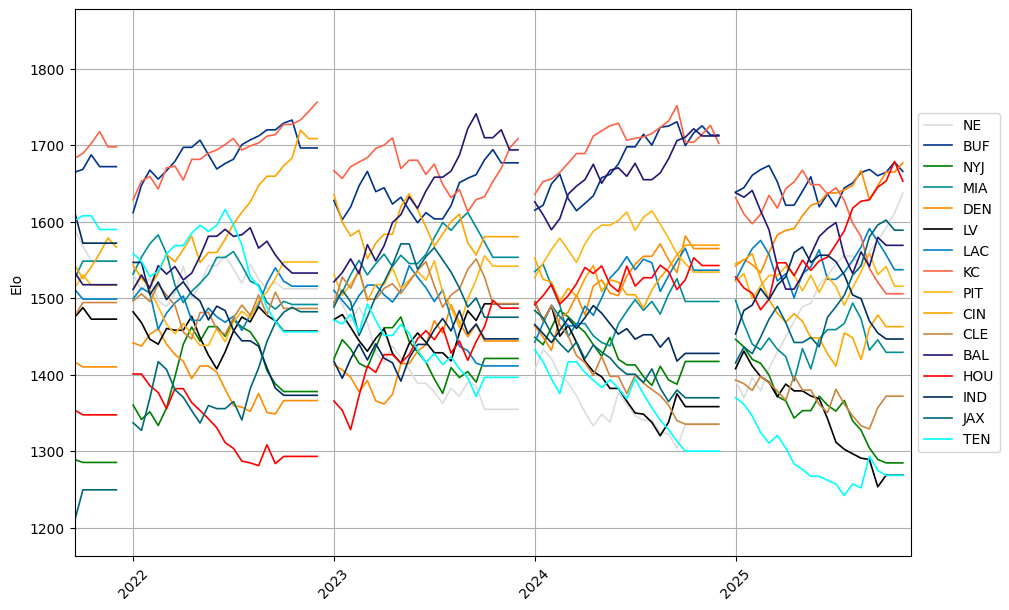

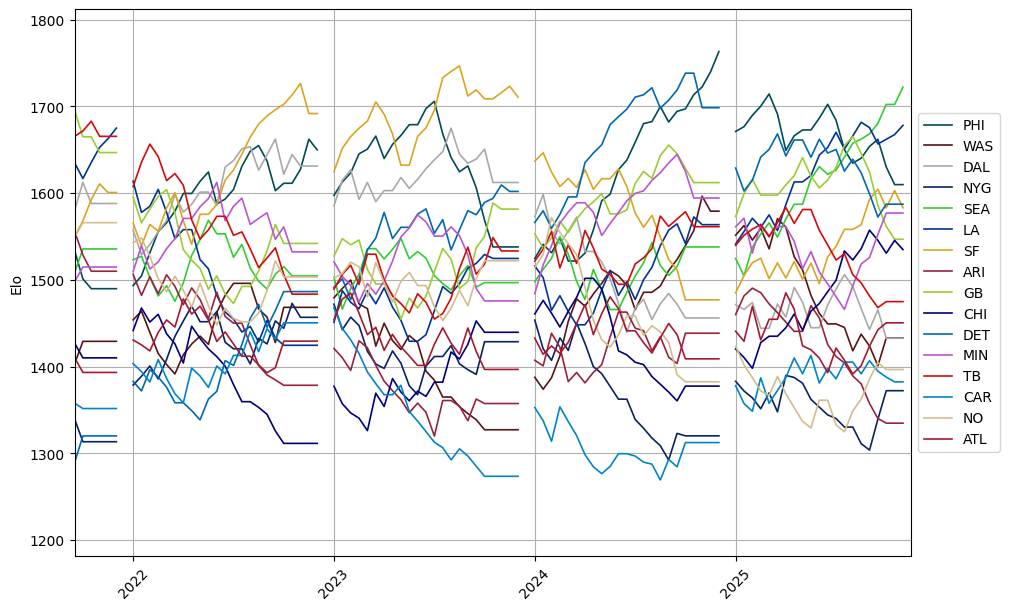

In [6]:
year_starts = [i for i,(yy,wk) in enumerate(time_hist) if wk == 1 and i != 0]
year_starts_set = set(year_starts)
def map_index(i):
    """Map original index i -> new index after inserting NaNs before each year start."""
    # number of inserted NaNs before position i
    return i + sum(s <= i for s in year_starts)



plt.figure(figsize=(10,6))
for t in ["NE", "BUF",'NYJ','MIA','DEN','LV','LAC','KC','PIT','CIN','CLE','BAL','HOU','IND','JAX','TEN']:
    y0 = [1500] + elo_hist[t][0:-1]

    y = []
    for i, v in enumerate(y0):
        if i in year_starts_set:     # insert break BEFORE week 1 point
            y.append(np.nan)
        y.append(v)

    plt.plot(y, label=t, color=teamcolor[t], lw=1.2)

plt.grid()
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()

# --- fixed ticks ---
xticks0 = [i for i,(yy,wk) in enumerate(time_hist) if wk == 1]     # original indices
xticks  = [map_index(i) for i in xticks0]                         # shifted indices
xlabels = [str(time_hist[i][0]) for i in xticks0]
plt.xticks(xticks, xlabels, rotation=45)
plt.xlim(500,600)
#plt.ylim(32.5,0.5)
plt.ylabel("Elo")
plt.show()
plt.figure(figsize=(10,6))
for t in ['PHI','WAS','DAL','NYG','SEA','LA','SF','ARI','GB','CHI','DET','MIN','TB','CAR','NO','ATL']:
    y0 = [1500] + elo_hist[t][0:-1]

    y = []
    for i, v in enumerate(y0):
        if i in year_starts_set:     # insert break BEFORE week 1 point
            y.append(np.nan)
        y.append(v)

    plt.plot(y, label=t, color=teamcolor[t], lw=1.2)

plt.grid()
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()

# --- fixed ticks ---
xticks0 = [i for i,(yy,wk) in enumerate(time_hist) if wk == 1]     # original indices
xticks  = [map_index(i) for i in xticks0]                         # shifted indices
xlabels = [str(time_hist[i][0]) for i in xticks0]
plt.xticks(xticks, xlabels, rotation=45)
plt.xlim(500,600)
#plt.ylim(32.5,0.5)
plt.ylabel("Elo")
plt.show()

In [8]:

print('Win probability for DEN: ', round(100*win_prob("DEN","NE",ratings),1),'%')
print('Win probability for SEA: ', round(100*win_prob("SEA","LA",ratings),1),'%')

#print(max(rank_hist['CLE'][500:]))
for t in teams:
    print(t,': ', np.round(np.sum(np.array(rank_hist[t][42:]) <= 16)/22.2,1))

Win probability for DEN:  49.3 %
Win probability for SEA:  63.9 %
DET :  7.3
CHI :  10.5
GB :  20.0
MIN :  14.1
TB :  10.2
NO :  14.7
CAR :  10.5
ATL :  10.8
PHI :  19.5
NYG :  9.1
WAS :  4.5
DAL :  15.5
SF :  11.8
SEA :  17.7
ARI :  6.6
LA :  9.8
PIT :  21.5
CLE :  3.0
CIN :  12.3
BAL :  20.1
JAX :  5.8
TEN :  10.3
HOU :  8.2
IND :  15.5
NE :  21.0
NYJ :  6.5
MIA :  8.1
BUF :  11.3
DEN :  13.2
LV :  3.1
KC :  17.2
LAC :  14.9


In [136]:
Seeds={"A1":"DEN","A2":"NE","A3":"JAX","A4":"PIT","A5":"HOU","A6":"BUF","A7":"LAC",
 "N1":"SEA","N2":"CHI","N3":"PHI","N4":"CAR","N5":"LA","N6":"SF","N7":"GB"}
SeedByTeam = {team: seed for seed, team in Seeds.items()}

In [137]:
sims=1000001

rd1winners = []
rd1losers = []
DivisionalWinners = []
ConferenceWinners = []
SBWinners = []

for i in range(sims):

    Rd1matchups = [
        [Seeds['A2'], Seeds['A7']],
        [Seeds['A3'], Seeds['A6']],
        [Seeds['A4'], Seeds['A5']],
        [Seeds['N2'], Seeds['N7']],
        [Seeds['N3'], Seeds['N6']],
        [Seeds['N4'], Seeds['N5']],
    ]

    rd1winners.append([])
    rd1losers.append([])
    DivisionalWinners.append([])
    ConferenceWinners.append([])
    SBWinners.append([])

    # --- Round 1 ---
    for game in Rd1matchups:
        if rng.random(size=None) < win_prob(game[0], game[1], ratings):
            rd1winners[i].append(game[0])
            rd1losers[i].append(game[1])
        else:
            rd1winners[i].append(game[1])
            rd1losers[i].append(game[0])

    # At this point rd1winners[i] is a list of 6 seed strings, e.g. ['A2','A4','A8','N2','N3','N5']

    # Split AFC/NFC and sort by numeric seed
    A_seeds = sorted(
        [SeedByTeam[t] for t in rd1winners[i] if SeedByTeam[t].startswith("A")],
        key=lambda s: int(s[1:])
    )
    N_seeds = sorted(
        [SeedByTeam[t] for t in rd1winners[i] if SeedByTeam[t].startswith("N")],
        key=lambda s: int(s[1:])
    )

# Build division-round matchups in terms of *teams*
    DivisionMatchups = [
        [Seeds["A1"], Seeds[A_seeds[-1]]],   # A1 vs highest remaining A seed
        [Seeds["N1"], Seeds[N_seeds[-1]]],   # N1 vs highest remaining N seed
        [Seeds[A_seeds[0]], Seeds[A_seeds[1]]],  # two lower A seeds (middle is index 1)
        [Seeds[N_seeds[0]], Seeds[N_seeds[1]]],  # two lower N seeds
    ]

    # Division round winners for this sim
    for game2 in DivisionMatchups:
        if rng.random(size=None) < win_prob(game2[0], game2[1], ratings):
            DivisionalWinners[i].append(game2[0])
        else:
            DivisionalWinners[i].append(game2[1])
    A_seeds = sorted(
        [SeedByTeam[t] for t in DivisionalWinners[i] if SeedByTeam[t].startswith("A")],
        key=lambda s: int(s[1:])
    )
    N_seeds = sorted(
        [SeedByTeam[t] for t in DivisionalWinners[i] if SeedByTeam[t].startswith("N")],
        key=lambda s: int(s[1:])
    )
    
    ConferenceMatchups = [
        [Seeds[A_seeds[0]], Seeds[A_seeds[1]]], 
        [Seeds[N_seeds[0]], Seeds[N_seeds[1]]]
    ]
    for game3 in ConferenceMatchups:
        if rng.random(size=None) < win_prob(game3[0], game3[1], ratings):
            ConferenceWinners[i].append(game3[0])
        else:
            ConferenceWinners[i].append(game3[1])
    if rng.random(size=None) < win_prob(ConferenceWinners[i][0], ConferenceWinners[i][1], ratings,home_for_a=False):
        SBWinners[i].append(ConferenceWinners[i][0])
    else:
        SBWinners[i].append(ConferenceWinners[i][1])
        


In [138]:
count_NE_rd1 = sum(row.count("NE") for row in rd1winners)
count_NE_1andDone = sims-count_NE_rd1
count_NE_divwin=sum(row.count("NE") for row in DivisionalWinners)
count_NE_confwin=sum(row.count("NE") for row in ConferenceWinners)
count_NE_SBwin=sum(row.count("NE") for row in SBWinners)
print(round(count_NE_SBwin/sims*100,2))

7.27


In [139]:
print(count_NE_confwin/sims*100)

16.813583186416814
